# Stage 1 + full-history tag attribution

We extract the coinbase tag for **every
block in Bitcoin's history** once, cache it to a Parquet file, and from then on
all downstream work loads that file for free, the "cache every stage" principle
your roadmap calls non-negotiable.

Output: first genuine full-history deliverable, the **longitudinal coverage
chart (LR4)** , plus first look at decentralisation over time.

Still tag-only (heuristic H1); the expensive address half is a separate step.
Run top to bottom; same `PROJECT_ID`.

In [1]:
%matplotlib inline
import json, os, re
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from google.cloud import bigquery

PROJECT_ID =  "project-9536b219-93fb-4fca-aac" 
client = bigquery.Client(project=PROJECT_ID)

pools = json.load(open("../data/raw/pools.json", encoding="utf-8"))
coinbase_tags = pools["coinbase_tags"]

# fast matcher: one regex over all tags, longest-first so specific tags win
TAGS = sorted(coinbase_tags.items(), key=lambda kv: len(kv[0]), reverse=True)
TAG_RE = re.compile("(" + "|".join(re.escape(t) for t, _ in TAGS) + ")")
TAG_TO_POOL = {t: m["name"] for t, m in coinbase_tags.items()}

def decode_coinbase(hex_str):
    if not hex_str:
        return ""
    try:
        return bytes.fromhex(hex_str).decode("utf-8", errors="ignore")
    except (ValueError, TypeError):
        return str(hex_str)

def match_by_tag(text):
    m = TAG_RE.search(text)
    return TAG_TO_POOL[m.group(1)] if m else "unknown"

print(f"{len(coinbase_tags)} tags loaded")

149 tags loaded


## Step 1 - extract the whole chain (once), then cache


In [2]:
RAW_PATH = "../data/raw/raw_blocks.parquet"

if os.path.exists(RAW_PATH):
    raw = pd.read_parquet(RAW_PATH)
    print(f"loaded {len(raw):,} blocks from cache")
else:
    QUERY = """
    SELECT number AS height, timestamp, coinbase_param
    FROM `bigquery-public-data.crypto_bitcoin.blocks`
    ORDER BY number
    """
    dry = client.query(QUERY, bigquery.QueryJobConfig(dry_run=True, use_query_cache=False))
    gb = dry.total_bytes_processed / 1e9
    print(f"will scan ~{gb:.2f} GB (one time only)")
    assert gb < 5, "Unexpectedly large for the blocks table — investigate."
    raw = client.query(QUERY).to_dataframe()
    os.makedirs("../data/raw", exist_ok=True)
    raw.to_parquet(RAW_PATH)
    print(f"extracted and cached {len(raw):,} blocks")

loaded 954,375 blocks from cache


## Step 2 - attribute every block by tag

Decode each coinbase, match against the full list. Thanks to the regex matcher
this runs over ~954k blocks in a few seconds, and we cache the result too.

In [3]:
raw["coinbase_text"] = raw["coinbase_param"].apply(decode_coinbase)
raw["pool"] = raw["coinbase_text"].apply(match_by_tag)

ATTR_PATH = "../data/derived/attributed_tags.parquet"
os.makedirs("../data/derived", exist_ok=True)
raw[["height", "timestamp", "pool"]].to_parquet(ATTR_PATH)

unknown_rate = (raw["pool"] == "unknown").mean()
print(f"overall unknown rate (all history): {unknown_rate:.1%}")
print(f"distinct pools seen: {raw['pool'].nunique()}")
print("\ntop 10 pools all-time:")
print(raw["pool"].value_counts().head(10).to_string())

overall unknown rate (all history): 30.0%
distinct pools seen: 109

top 10 pools all-time:
pool
unknown         285966
AntPool         107908
F2Pool           96600
Foundry USA      71063
ViaBTC           51596
Braiins Pool     41874
CloverPool       37796
BTC Guild        32935
Poolin           26015
Binance Pool     21897


## Step 3 - the deliverable: coverage and concentration over time

Two panels sharing a timeline:

- **Top (LR4):** what fraction of blocks you can attribute, by year. It starts low
  (untagged early solo mining) and climbs as pools adopted coinbase tags.
- **Bottom:** the Nakamoto coefficient (known pools only) by year.

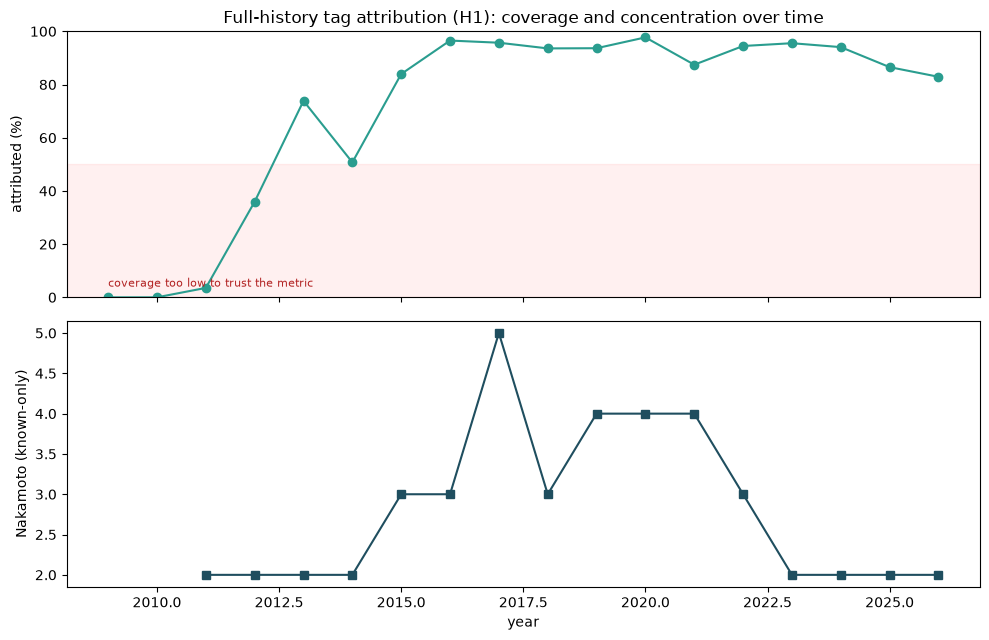

In [4]:
def nakamoto_coefficient(entity_counts):
    shares = pd.Series(entity_counts).sort_values(ascending=False)
    total = shares.sum()
    if total == 0:
        return np.nan
    cum = 0
    for i, (_e, n) in enumerate(shares.items(), start=1):
        cum += n
        if cum / total > 0.5:
            return i
    return len(shares)

raw["year"] = pd.to_datetime(raw["timestamp"]).dt.year
years = sorted(raw["year"].unique())

cov = raw.assign(known=raw["pool"] != "unknown").groupby("year")["known"].mean()
nak = pd.Series({
    y: nakamoto_coefficient(
        raw.loc[(raw["year"] == y) & (raw["pool"] != "unknown"), "pool"].value_counts())
    for y in years
})

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6.5), sharex=True)
ax1.plot(cov.index, cov.values * 100, "o-", color="#2a9d8f")
ax1.axhspan(0, 50, color="red", alpha=0.06)
ax1.text(years[0], 4, "coverage too low to trust the metric", fontsize=8, color="firebrick")
ax1.set_ylabel("attributed (%)")
ax1.set_ylim(0, 100)
ax1.set_title("Full-history tag attribution (H1): coverage and concentration over time")

ax2.plot(nak.index, nak.values, "s-", color="#1f4e5f")
ax2.set_ylabel("Nakamoto (known-only)")
ax2.set_xlabel("year")

fig.tight_layout()
os.makedirs("../figures", exist_ok=True)
fig.savefig("../figures/fullhistory_coverage.png", dpi=120, bbox_inches="tight")
plt.show()